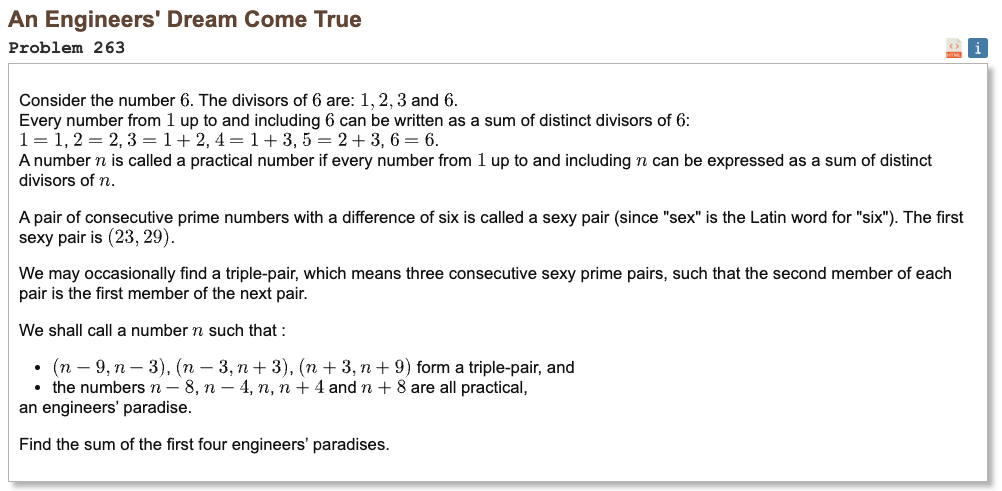

## Initial approach

* We need 4 primes: n-9, n-3, n+3, n+9
* They must be three consecutive sexy prime pairs:
(n-9, n-3), (n-3, n+3), (n+3, n+9)
That also means there is no prime between each pair (so +2 and +4 steps must be composite).
* Also, 5 numbers must be practical: n-8, n-4, n, n+4, n+8.
* Practical test uses the standard prime-factor rule (sort prime factors, keep a running reachable-sum bound using the divisor-sum multiplier).

In [1]:
import math

def simple_sieve(limit: int) -> list[int]:
    bs = bytearray(b"\x01") * (limit + 1)
    bs[0:2] = b"\x00\x00"
    r = int(limit**0.5)
    for i in range(2, r + 1):
        if bs[i]:
            start = i * i
            step = i
            bs[start:limit + 1:step] = b"\x00" * (((limit - start) // step) + 1)
    return [i for i in range(limit + 1) if bs[i]]

def factorize_trial(n: int, primes: list[int]) -> list[tuple[int, int]]:
    x = n
    out = []
    for p in primes:
        if p * p > x:
            break
        if x % p == 0:
            a = 0
            while x % p == 0:
                x //= p
                a += 1
            out.append((p, a))
    if x > 1:
        out.append((x, 1))
    return out

def is_practical(n: int, primes: list[int]) -> bool:
    if n == 1:
        return True
    fac = factorize_trial(n, primes)
    if not fac or fac[0][0] != 2:
        return False
    sigma_prefix = 1
    for p, a in fac:
        if p != 2 and p > sigma_prefix + 1:
            return False
        sigma_prefix *= (p ** (a + 1) - 1) // (p - 1)
    return True

def solve() -> int:
    limit = 1_300_000_000
    need = 4
    segment_size = 10_000_000

    base_primes = simple_sieve(50_000)
    sqrt_lim = int((limit + 20) ** 0.5) + 1
    small = [p for p in base_primes if p <= sqrt_lim]

    found = []
    low = 3
    if low % 2 == 0:
        low += 1

    while low <= limit and len(found) < need:
        high = min(low + segment_size, limit + 20)
        if high % 2 == 0:
            high += 1

        size = (high - low) // 2
        is_prime = bytearray(b"\x01") * size

        for p in small[1:]:
            pp = p * p
            if pp >= high:
                break
            start = pp if pp > low else ((low + p - 1) // p) * p
            if start % 2 == 0:
                start += p
            step = 2 * p
            idx = (start - low) // 2
            stride = step // 2
            count = ((size - 1 - idx) // stride) + 1
            is_prime[idx:size:stride] = b"\x00" * count

        for i in range(size):
            if not is_prime[i]:
                continue
            p = low + 2 * i
            if p + 18 >= high:
                break

            i6 = (p + 6 - low) // 2
            i12 = (p + 12 - low) // 2
            i18 = (p + 18 - low) // 2
            if not (is_prime[i6] and is_prime[i12] and is_prime[i18]):
                continue

            ok = True
            for off in (2, 4, 8, 10, 14, 16):
                q = p + off
                if q >= high:
                    ok = False
                    break
                if is_prime[(q - low) // 2]:
                    ok = False
                    break
            if not ok:
                continue

            n = p + 9
            if all(is_practical(x, base_primes) for x in (n - 8, n - 4, n, n + 4, n + 8)):
                found.append(n)
                if len(found) == need:
                    break

        low = high

    return sum(found)

In [2]:
%%time
solve()

CPU times: user 22.4 s, sys: 161 ms, total: 22.6 s
Wall time: 22.7 s


2039506520